Argentine Inflation Tracker: High-Frequency Price Monitoring
Project Overview: > This project aims to monitor inflation in Argentina by scraping real-time price data from major retailers. Given the country's inflationary context, high-frequency data collection is essential for understanding price dynamics beyond official monthly reports.

Methodology: > * Data Source: Carrefour Argentina (Almacén/Grocery section).

Frequency: Weekly captures to calculate WoW (Week-over-Week) variation.

Status:  In Development - Phase 1: Data Collection & Storage.

In [3]:
pip install selenium webdriver-manager

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 526.0 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.5 MB 526.0 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.5 MB 569.1 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/9.5 MB 569.1 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.5 MB 629.0 kB/s eta 0:00:14
   ---- ----------------------------------- 1.0/9.5 MB 629.0 kB/s eta 0:00:14
   ----- ---------------------------------- 1.3/9.5 MB 636.1 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.5 MB 636.1 kB/s eta 0:00:13
   ------ ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\agusm\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

def fetch_carrefour_almacen():
    
    url = "https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen"
    
    
    params = {
        "_from": 0,
        "_to": 49,
        "O": "OrderByTopSaleDESC"
    }

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "application/json"
    }

    try:
        print(f"[{datetime.now().strftime('%H:%M:%S')}] Conectando con Carrefour...")
        response = requests.get(url, params=params, headers=headers, timeout=15)
        response.raise_for_status()
        
        products_json = response.json()
        product_list = []
        
        for item in products_json:
            
            item_data = item['items'][0]
            commertial_offer = item_data['sellers'][0]['commertialOffer']
            
            
            reference_price = "N/A"
            
            
            all_specs = item.get('allSpecifications', [])
            for spec_name in all_specs:
                if 'unidad de medida' in spec_name.lower():
                    spec_values = item.get(spec_name)
                    if spec_values:
                        reference_price = spec_values[0]
                        break
            
            
            if reference_price == "N/A":
                unit = item_data.get('measurementUnit', '')
                multiplier = item_data.get('unitMultiplier', 1)
                if unit:
                    reference_price = f"{multiplier} {unit}"

            
            product_info = {
                "Fecha": datetime.now().strftime('%Y-%m-%d'),
                "Producto": item.get('productName'),
                "Marca": item.get('brand'),
                "Precio_Actual": commertial_offer.get('Price'),
                "Precio_Lista": commertial_offer.get('ListPrice'),
                "Unidad_Ref": reference_price,
                "Link": item.get('link')
            }
            product_list.append(product_info)
        
        
        df = pd.DataFrame(product_list)
        return df

    except Exception as e:
        print(f"Error detectado: {e}")
        return None

if __name__ == "__main__":
    df_results = fetch_carrefour_almacen()
    
    if df_results is not None and not df_results.empty:
        print("\n¡Datos recuperados con éxito!")
        print(df_results[['Producto', 'Precio_Actual', 'Unidad_Ref']].head())
        
        
        nombre_archivo = f"precios_almacen_{datetime.now().strftime('%Y%m%d')}.csv"
        df_results.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')
        print(f"\nArchivo guardado: {nombre_archivo}")
    else:
        print("No se pudieron obtener datos. Verificá la conexión.")

[13:17:51] Conectando con Carrefour...

¡Datos recuperados con éxito!
                                            Producto  Precio_Actual Unidad_Ref
0        Lomitos de atún Carrefour al natural 170 g.        2934.80        GRM
1                   Puré de tomate Arcor brik 520 g.         719.00        GRM
2                Fideos tallarin N5 Lucchetti 500 g.        1499.00        GRM
3              Fideos tirabuzon N28 Lucchetti 500 g.        1499.00        GRM
4  Mayonesa Clásica Hellmanns sin tacc doypack 47...        2099.25        GRM

Archivo guardado: precios_almacen_20260308.csv


In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_carrefour_inflacion(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Iniciando relevamiento de Almacén...")

    for p in range(paginas):
        start = p * 50
        end = start + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            
            if not data:
                break

            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                
                
                unit = item_data.get('measurementUnit', 'un')
                if unit == 'GRM': unit = 'g'
                if unit == 'MLT': unit = 'ml'
                if unit == 'KGM': unit = 'kg'

                all_products.append({
                    "Fecha": datetime.now().strftime('%Y-%m-%d'),
                    "Producto": item.get('productName'),
                    "Marca": item.get('brand'),
                    "Precio": commertial_offer.get('Price'),
                    "Unidad": f"{item_data.get('unitMultiplier', 1)} {unit}",
                    "Categoria": "Almacen"
                })
            
            print(f" > Página {p+1} procesada ({len(all_products)} productos acumulados)")
            time.sleep(1) 

        except Exception as e:
            print(f" Error en página {p+1}: {e}")
            break

    return pd.DataFrame(all_products)


df_final = scrape_carrefour_inflacion(paginas=5) 

if not df_final.empty:
    filename = f"canasta_carrefour_{datetime.now().strftime('%Y%m%d')}.csv"
    df_final.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\n¡Listo! Se guardaron {len(df_final)} productos en {filename}")
    print(df_final.head())

[13:19:11] Iniciando relevamiento de Almacén...
 > Página 1 procesada (50 productos acumulados)
 > Página 2 procesada (100 productos acumulados)
 > Página 3 procesada (150 productos acumulados)
 > Página 4 procesada (200 productos acumulados)
 > Página 5 procesada (250 productos acumulados)

¡Listo! Se guardaron 250 productos en canasta_carrefour_20260308.csv
        Fecha                                           Producto      Marca  \
0  2026-03-08        Lomitos de atún Carrefour al natural 170 g.  Carrefour   
1  2026-03-08                   Puré de tomate Arcor brik 520 g.      Arcor   
2  2026-03-08                Fideos tallarin N5 Lucchetti 500 g.  Matarazzo   
3  2026-03-08              Fideos tirabuzon N28 Lucchetti 500 g.   Luchetti   
4  2026-03-08  Mayonesa Clásica Hellmanns sin tacc doypack 47...  Hellmanns   

    Precio  Unidad Categoria  
0  2934.80  1.0 un   Almacen  
1   719.00  1.0 un   Almacen  
2  1499.00  1.0 un   Almacen  
3  1499.00  1.0 un   Almacen  
4  2099.

UPDATE 3/15/2026

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_carrefour_inflacion(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Iniciando relevamiento de Almacén...")

    for p in range(paginas):
        
        start = p * 50
        end = start + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            
            if not data:
                break

            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                
                
                unit = item_data.get('measurementUnit', 'un')
                if unit == 'GRM': unit = 'g'
                if unit == 'MLT': unit = 'ml'
                if unit == 'KGM': unit = 'kg'

                all_products.append({
                    "Fecha": datetime.now().strftime('%Y-%m-%d'),
                    "Producto": item.get('productName'),
                    "Marca": item.get('brand'),
                    "Precio_S2": commertial_offer.get('Price'), 
                    "Unidad": f"{item_data.get('unitMultiplier', 1)} {unit}"
                })
            
            print(f" > Página {p+1} procesada ({len(all_products)} productos acumulados)")
            time.sleep(1.5) 

        except Exception as e:
            print(f" Error en página {p+1}: {e}")
            break

    return pd.DataFrame(all_products)


df_hoy = scrape_carrefour_inflacion(paginas=5) 

if not df_hoy.empty:
    
    filename = f"precios_almacen_{datetime.now().strftime('%Y%m%d')}.csv"
    df_hoy.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\n¡Listo! Archivo guardado como: {filename}")
else:
    print("No se pudieron obtener datos.")

[11:19:27] Iniciando relevamiento de Almacén...
 > Página 1 procesada (50 productos acumulados)
 > Página 2 procesada (100 productos acumulados)
 > Página 3 procesada (150 productos acumulados)
 > Página 4 procesada (200 productos acumulados)
 > Página 5 procesada (250 productos acumulados)

¡Listo! Archivo guardado como: precios_almacen_20260315.csv


Comparison between the previous week and this one:

In [12]:
import pandas as pd


df_viejos = pd.read_csv("precios_almacen_20260308.csv")
df_nuevos = pd.read_csv("precios_almacen_20260315.csv")


df_final = pd.merge(df_viejos, df_nuevos, on=["Producto", "Marca"], suffixes=('_Semana1', '_Semana2'))


df_final['Variacion_Semanas_%'] = ((df_final['Precio_S2'] / df_final['Precio_Actual']) - 1) * 100


inflacion_canasta = df_final['Variacion_Semanas_%'].mean()

print(f"--- REPORTE DE INFLACIÓN SEMANAL - UBA ---")
print(f"Productos comparados con éxito: {len(df_final)}")
print(f"Inflación promedio de la semana: {inflacion_canasta:.2f}%")


df_final.to_csv("reporte_comparativo_final.csv", index=False, encoding='utf-8-sig')
print("\n¡Reporte guardado como 'reporte_comparativo_final.csv'!")

--- REPORTE DE INFLACIÓN SEMANAL - UBA ---
Productos comparados con éxito: 50
Inflación promedio de la semana: 2.07%

¡Reporte guardado como 'reporte_comparativo_final.csv'!


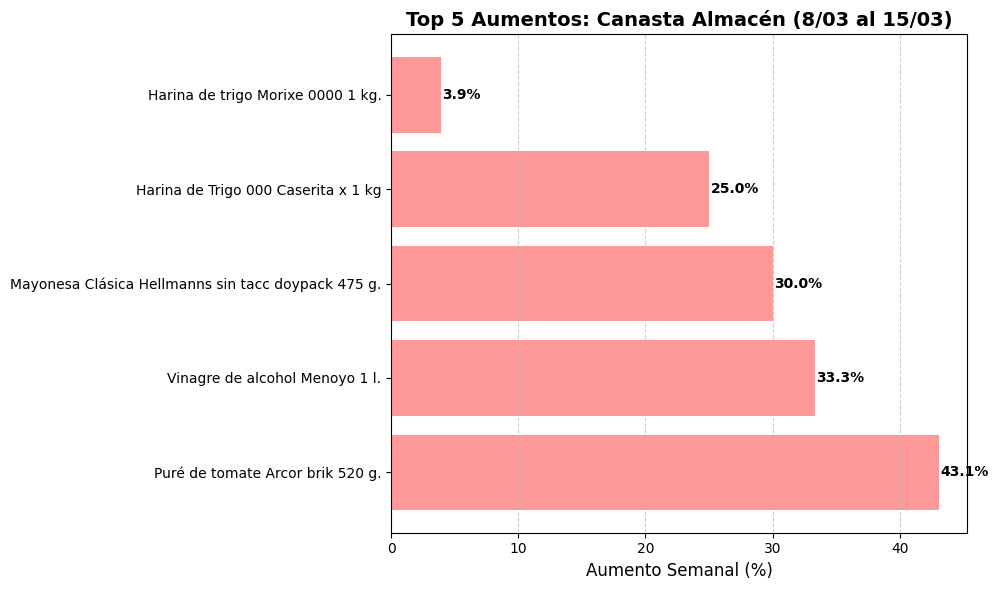

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df_reporte = pd.read_csv("reporte_comparativo_final.csv")


top_5 = df_reporte.sort_values(by='Variacion_Semanas_%', ascending=False).head(5)


plt.figure(figsize=(10, 6))
plt.barh(top_5['Producto'], top_5['Variacion_Semanas_%'], color='#ff9999')


plt.xlabel('Aumento Semanal (%)', fontsize=12)
plt.title('Top 5 Aumentos: Canasta Almacén (8/03 al 15/03)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)


for i, v in enumerate(top_5['Variacion_Semanas_%']):
    plt.text(v + 0.1, i, f"{v:.1f}%", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

This project tracks weekly inflation for the 'Almacén' (Grocery) category at Carrefour Argentina using an automated API-based scraping approach. By comparing a consistent sample of 50 products between March 8 and March 15, the analysis revealed a weekly inflation rate of 2.07%. While the average remains relatively stable, the data shows high price dispersion, with specific items (such as tomato purée and condiments) recording spikes of over 30% following the expiration of seasonal promotions. This high-frequency monitoring method is essential for capturing inflationary dynamics that standard monthly CPI reports might smooth over.

NEXT UPDATE 3/22/2026

Today is 3/22/2026, let's make the week analysis

In [1]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_semana_3(paginas=5):
    all_products = []
    headers = {"User-Agent": "Mozilla/5.0"}
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Iniciando relevamiento SEMANA 3...")

    for p in range(paginas):
        start, end = p * 50, p * 50 + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        try:
            res = requests.get(url, headers=headers, timeout=15)
            data = res.json()
            for item in data:
                item_data = item['items'][0]
                price = item_data['sellers'][0]['commertialOffer']['Price']
                unit = item_data.get('measurementUnit', 'un').replace('GRM','g').replace('MLT','ml').replace('KGM','kg')
                all_products.append({
                    "Fecha": "2026-03-22",
                    "Producto": item.get('productName'),
                    "Marca": item.get('brand'),
                    "Precio_S3": price,
                    "Unidad": f"{item_data.get('unitMultiplier', 1)} {unit}"
                })
            time.sleep(1.5)
        except: break
    return pd.DataFrame(all_products)

df_s3 = scrape_semana_3()
df_s3.to_csv("precios_almacen_20260322.csv", index=False, encoding='utf-8-sig')
print("¡Archivo precios_almacen_20260322.csv guardado!")

[11:57:48] Iniciando relevamiento SEMANA 3...
¡Archivo precios_almacen_20260322.csv guardado!


comparison 

In [5]:
for df in [df1, df2, df3]:
    df['Producto'] = df['Producto'].str.strip().str.lower()
    df['Marca'] = df['Marca'].str.strip().str.lower()

In [6]:
df_series = df1.merge(df2, on=["Producto", "Marca"]).merge(df3, on=["Producto", "Marca"])

# Variación semana 1 → semana 2
df_series['Var_S1_S2_%'] = ((df_series['Precio_S2'] / df_series['Precio_Actual']) - 1) * 100

# Variación semana 1 → semana 3 (acumulada)
df_series['Var_Acumulada_%'] = ((df_series['Precio_S3'] / df_series['Precio_Actual']) - 1) * 100

print(f"Inflación S1→S2: {df_series['Var_S1_S2_%'].mean():.2f}%")
print(f"Inflación Acumulada (15 días): {df_series['Var_Acumulada_%'].mean():.2f}%")

Inflación S1→S2: 2.12%
Inflación Acumulada (15 días): -0.16%


Eso te va a decir si el -0.16% es porque la mayoría de productos bajaron un poco, o si hubo muchos que subieron pero algunos que bajaron mucho y "tiraron" el promedio hacia abajo.

In [8]:
# Ver cuántos productos bajaron vs subieron
print(df_series['Var_Acumulada_%'].describe())
print(f"\nProductos que subieron: {(df_series['Var_Acumulada_%'] > 0).sum()}")
print(f"Productos que bajaron:  {(df_series['Var_Acumulada_%'] < 0).sum()}")
print(f"Sin cambio:             {(df_series['Var_Acumulada_%'] == 0).sum()}")

count    49.000000
mean     -0.162534
std      11.748703
min     -28.763979
25%       0.000000
50%       0.000000
75%       0.000000
max      43.115438
Name: Var_Acumulada_%, dtype: float64

Productos que subieron: 6
Productos que bajaron:  8
Sin cambio:             35


35 de 49 productos (71%) no cambiaron de precio en 15 días. Eso es lo más importante. La mediana es exactamente 0, lo que confirma que la mayoría de los precios están completamente quietos.
De los que sí cambiaron, 8 bajaron y 6 subieron, con una dispersión enorme (std de 11.7) — hay un producto que subió 43% y otro que bajó 28%. Esos outliers son casi con certeza promociones que empezaron o terminaron, no inflación real.

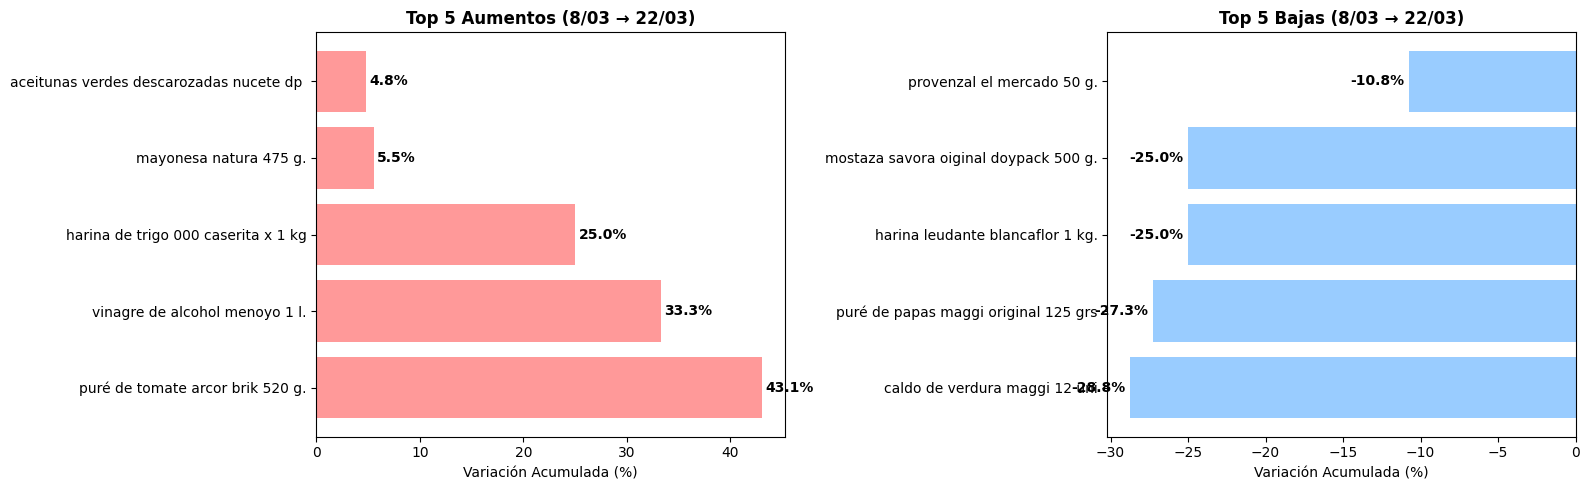

In [9]:
import matplotlib.pyplot as plt

# Top 5 que más subieron (acumulado)
top_subieron = df_series.sort_values('Var_Acumulada_%', ascending=False).head(5)

# Top 5 que más bajaron (acumulado)
top_bajaron = df_series.sort_values('Var_Acumulada_%', ascending=True).head(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico subidas
ax1.barh(top_subieron['Producto'].str[:40], top_subieron['Var_Acumulada_%'], color='#ff9999')
ax1.set_title('Top 5 Aumentos (8/03 → 22/03)', fontweight='bold')
ax1.set_xlabel('Variación Acumulada (%)')
for i, v in enumerate(top_subieron['Var_Acumulada_%']):
    ax1.text(v + 0.3, i, f"{v:.1f}%", va='center', fontweight='bold')

# Gráfico bajas
ax2.barh(top_bajaron['Producto'].str[:40], top_bajaron['Var_Acumulada_%'], color='#99ccff')
ax2.set_title('Top 5 Bajas (8/03 → 22/03)', fontweight='bold')
ax2.set_xlabel('Variación Acumulada (%)')
for i, v in enumerate(top_bajaron['Var_Acumulada_%']):
    ax2.text(v - 0.3, i, f"{v:.1f}%", va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_carrefour(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Iniciando relevamiento...")

    for p in range(paginas):
        start, end = p * 50, p * 50 + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            
            if not data:
                break

            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                
                unit = item_data.get('measurementUnit', 'un')
                unit = unit.replace('GRM', 'g').replace('MLT', 'ml').replace('KGM', 'kg')

                all_products.append({
                    "Fecha": datetime.now().strftime('%Y-%m-%d'),
                    "Producto": item.get('productName').strip().lower(),
                    "Marca": item.get('brand').strip().lower(),
                    "Precio": commertial_offer.get('Price'),
                    "Precio_Lista": commertial_offer.get('ListPrice'),
                    "Unidad": f"{item_data.get('unitMultiplier', 1)} {unit}"
                })
            
            print(f" > Página {p+1} procesada ({len(all_products)} productos acumulados)")
            time.sleep(1.5)

        except Exception as e:
            print(f" Error en página {p+1}: {e}")
            break

    return pd.DataFrame(all_products)


df_hoy = scrape_carrefour(paginas=5)

if not df_hoy.empty:
    filename = f"precios_almacen_{datetime.now().strftime('%Y%m%d')}.csv"
    df_hoy.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\n¡Listo! {len(df_hoy)} productos guardados en '{filename}'")
    print(df_hoy[['Producto', 'Precio', 'Precio_Lista']].head())
else:
    print("No se pudieron obtener datos.")

[12:38:44] Iniciando relevamiento...
 > Página 1 procesada (50 productos acumulados)
 > Página 2 procesada (100 productos acumulados)
 > Página 3 procesada (150 productos acumulados)
 > Página 4 procesada (200 productos acumulados)
 > Página 5 procesada (250 productos acumulados)

¡Listo! 250 productos guardados en 'precios_almacen_20260322.csv'
                                            Producto  Precio  Precio_Lista
0        lomitos de atún carrefour al natural 170 g.  2934.8        3190.0
1                   puré de tomate arcor brik 520 g.  1029.0        1029.0
2  choclo en granos amarillo carrefour classic en...  1060.2        1390.0
3                fideos tallarin n5 lucchetti 500 g.  1499.0        1499.0
4          mayonesa hellmanns liviana doypack 475 g.  2100.0        2800.0


lomitos de atún tiene Precio 2934.8 pero Precio_Lista 3190 — claramente está con descuento. Y la mayonesa Hellmanns tiene 2100 vs 2800, un descuento enorme.

Productos comparados: 49
Inflación acumulada (8/3 → 22/3) sin promos: 0.35%

Productos que subieron: 5
Productos que bajaron:  2
Sin cambio:             42


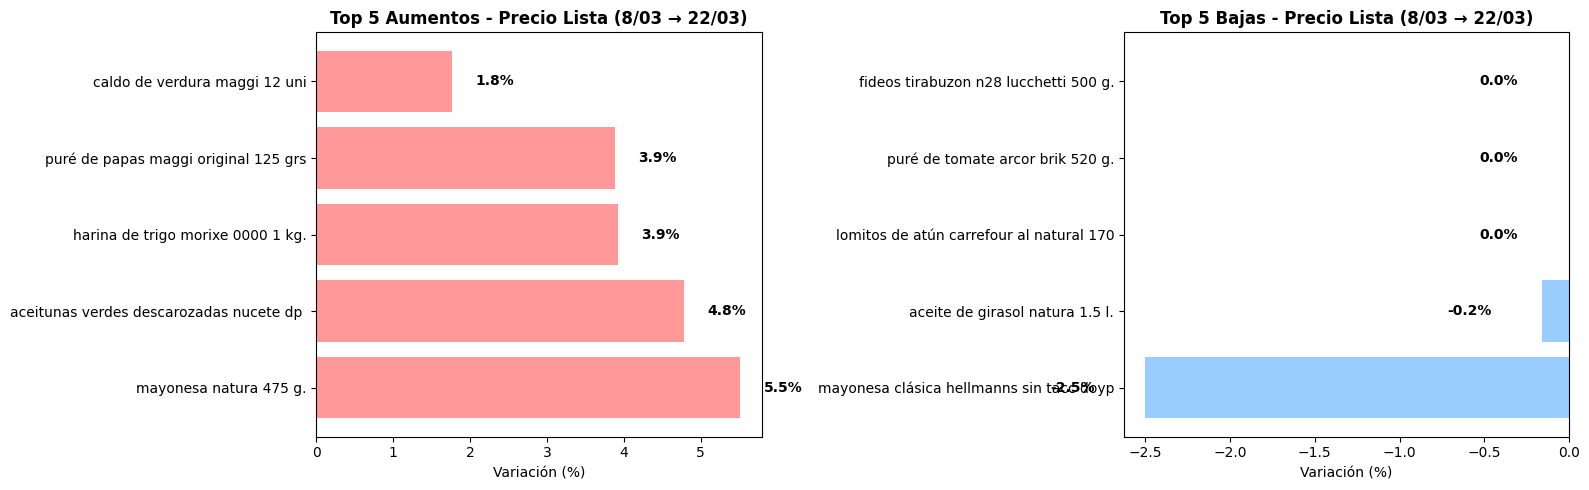

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar CSVs
df1 = pd.read_csv("precios_almacen_20260308.csv")
df_hoy = pd.read_csv("precios_almacen_20260322.csv")

# Normalizar nombres del CSV viejo (no tenía lowercase)
df1['Producto'] = df1['Producto'].str.strip().str.lower()
df1['Marca'] = df1['Marca'].str.strip().str.lower()

# Merge usando Precio_Lista (ambos CSVs la tienen)
df_merge = df1[['Producto', 'Marca', 'Precio_Lista']].merge(
    df_hoy[['Producto', 'Marca', 'Precio_Lista']],
    on=['Producto', 'Marca'],
    suffixes=('_S1', '_S4')
)

# Variación usando precio de lista (sin ruido promocional)
df_merge['Var_%'] = ((df_merge['Precio_Lista_S4'] / df_merge['Precio_Lista_S1']) - 1) * 100

print(f"Productos comparados: {len(df_merge)}")
print(f"Inflación acumulada (8/3 → 22/3) sin promos: {df_merge['Var_%'].mean():.2f}%")
print(f"\nProductos que subieron: {(df_merge['Var_%'] > 0).sum()}")
print(f"Productos que bajaron:  {(df_merge['Var_%'] < 0).sum()}")
print(f"Sin cambio:             {(df_merge['Var_%'] == 0).sum()}")

# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

top_subieron = df_merge.sort_values('Var_%', ascending=False).head(5)
top_bajaron = df_merge.sort_values('Var_%').head(5)

ax1.barh(top_subieron['Producto'].str[:40], top_subieron['Var_%'], color='#ff9999')
ax1.set_title('Top 5 Aumentos - Precio Lista (8/03 → 22/03)', fontweight='bold')
ax1.set_xlabel('Variación (%)')
for i, v in enumerate(top_subieron['Var_%']):
    ax1.text(v + 0.3, i, f"{v:.1f}%", va='center', fontweight='bold')

ax2.barh(top_bajaron['Producto'].str[:40], top_bajaron['Var_%'], color='#99ccff')
ax2.set_title('Top 5 Bajas - Precio Lista (8/03 → 22/03)', fontweight='bold')
ax2.set_xlabel('Variación (%)')
for i, v in enumerate(top_bajaron['Var_%']):
    ax2.text(v - 0.3, i, f"{v:.1f}%", va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.show()

Las "bajas" que antes veías (Maggi -28%, Savora -25%) desaparecieron completamente — confirma que eran 100% promociones, no deflación real.
Los aumentos reales son moderados: mayonesa +5.5%, aceitunas +4.8%, harina +3.9%. Nada explosivo, que tiene sentido para marzo 2026.
Y lo más importante: 42 de 49 productos sin cambio en precio de lista — Carrefour está congelando precios de lista y jugando con descuentos para atraer clientes.